<a href="https://colab.research.google.com/github/Abishekabi19/ML-and-DL-Project/blob/main/Heart_attack_project/Heart_attack_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

 The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Patients Data ( Used for Heart Disease Prediction ) (1) (1).csv')
df

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df['GeneralHealth'].replace(['Poor','Fair','Good','Very good','Excellent'],[1,2,3,4,5],inplace=True)

/tmp/ipython-input-130276327.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Poor','Fair','Good','Very good','Excellent'],[1,2,3,4,5],inplace=True)
/tmp/ipython-input-130276327.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'].replace(['Poor','

In [ ]:
print(df['ECigaretteUsage'].unique())

['Never used e-cigarettes in my entire life' 'Not at all (right now)'
 'Use them some days' 'Use them every day']


In [ ]:
df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life','Not at all (right now)','Use them some days','Use them every day'],
                              [1,2,3,4],inplace=True)

/tmp/ipython-input-3837715411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life','Not at all (right now)','Use them some days','Use them every day'],
/tmp/ipython-input-3837715411.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', T

In [ ]:
print(df['AgeCategory'].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
df['AgeCategory'].replace(["Age 18 to 24", "Age 25 to 29", "Age 30 to 34", "Age 35 to 39","Age 40 to 44","Age 45 to 49","Age 50 to 54","Age 55 to 59","Age 60 to 64","Age 65 to 69","Age 70 to 74", "Age 75 to 79","Age 80 or older"],
                           [1,2,3,4,5,6,7,8,9,10,11,12,13],inplace=True)


/tmp/ipython-input-2149783010.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace(["Age 18 to 24", "Age 25 to 29", "Age 30 to 34", "Age 35 to 39","Age 40 to 44","Age 45 to 49","Age 50 to 54","Age 55 to 59","Age 60 to 64","Age 65 to 69","Age 70 to 74", "Age 75 to 79","Age 80 or older"],
/tmp/ipython-input-2149783010.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])
df['SmokerStatus']=le.fit_transform(df['SmokerStatus'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])

In [ ]:
df

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,0,2,12,1.63,84.820000,32.099998,0,1,...,1,1,4,0,0,0,1,0,0,1
1,2,0,0,4,10,1.60,71.669998,27.990000,0,0,...,1,0,4,0,0,1,1,1,0,0
2,3,0,1,5,9,1.78,71.209999,22.530001,0,0,...,1,0,4,1,0,0,0,2,0,0
3,4,0,1,4,11,1.78,95.250000,30.129999,0,0,...,1,0,4,0,0,1,1,2,0,0
4,5,0,0,3,7,1.68,78.019997,27.760000,0,0,...,1,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,0,3,9,1.57,90.720001,36.580002,0,0,...,2,0,1,0,0,1,0,0,0,0
237626,237627,40,0,3,8,1.70,72.570000,25.059999,0,1,...,2,0,1,0,1,0,0,1,0,0
237627,237628,40,1,2,6,1.75,70.309998,22.889999,1,1,...,2,1,1,0,1,1,1,1,1,0
237628,237629,40,0,4,2,1.57,46.720001,18.840000,0,0,...,1,0,1,0,1,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
X = df.drop(columns=['HadHeartAttack'])
y = df['HadHeartAttack']


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

df_smote = pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name=y.name)],
    axis=1
)


In [ ]:
df=df_smote

<Axes: >

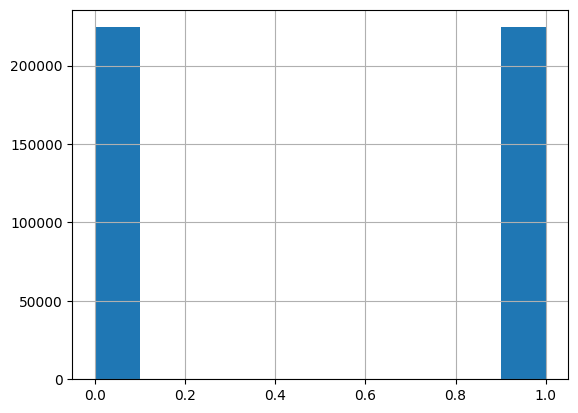

In [ ]:
df['HadHeartAttack'].hist()

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


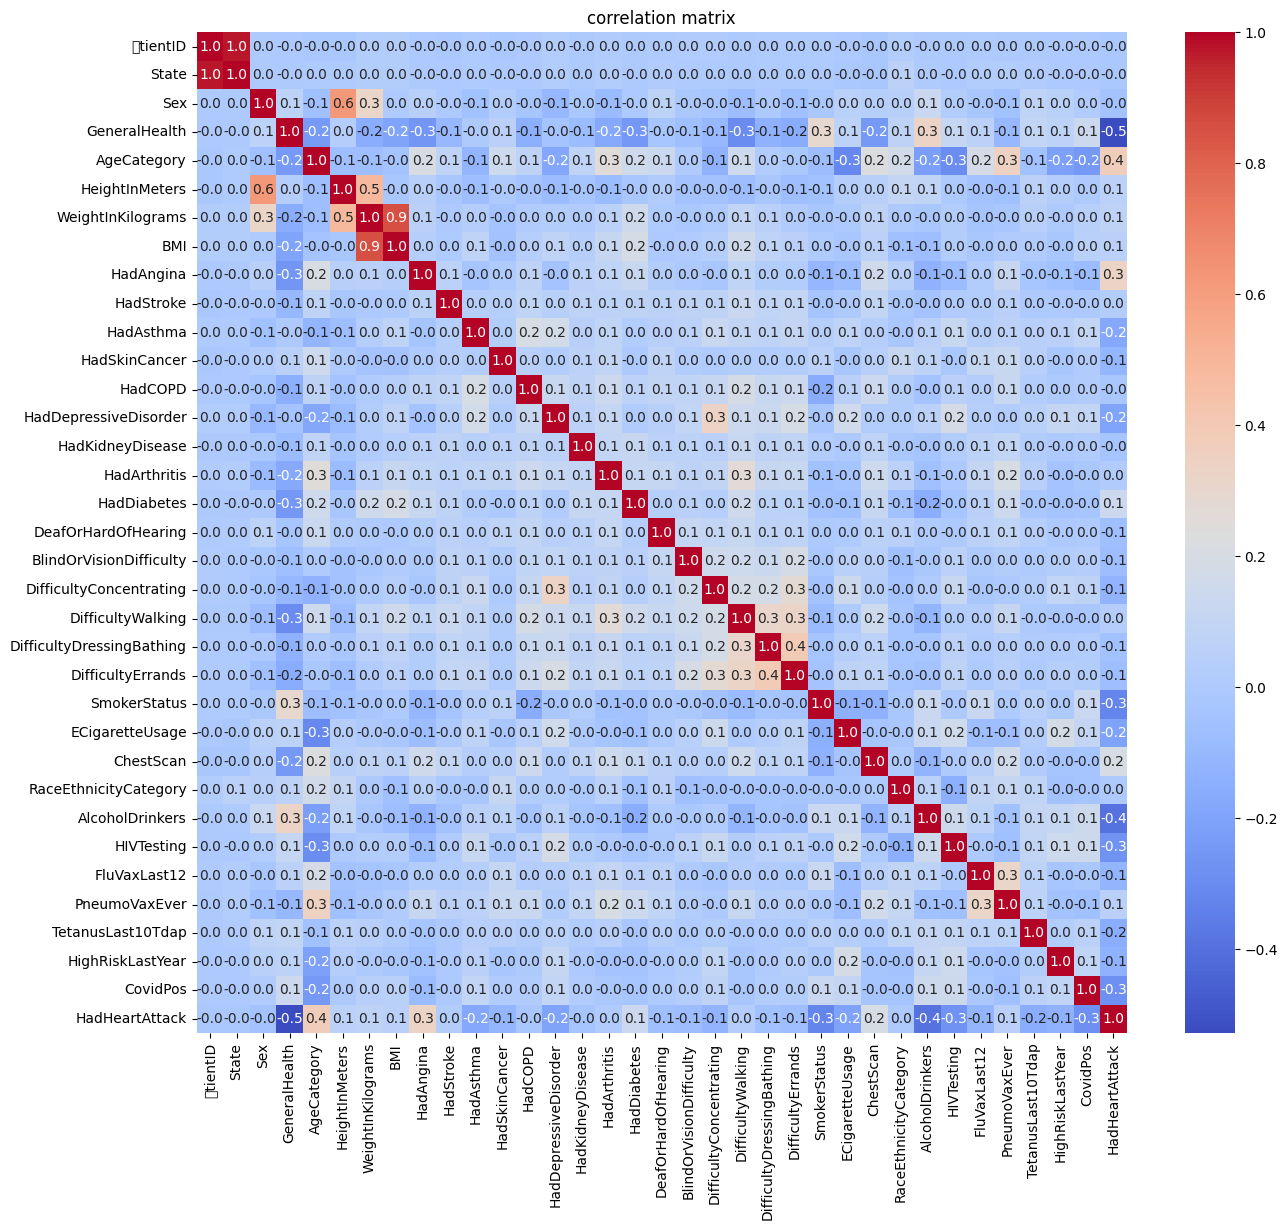

In [ ]:
plt.figure(figsize=(15,13))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.001f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop('tientID',axis=1,inplace=True)

In [ ]:
df.drop('WeightInKilograms',axis=1,inplace=True)

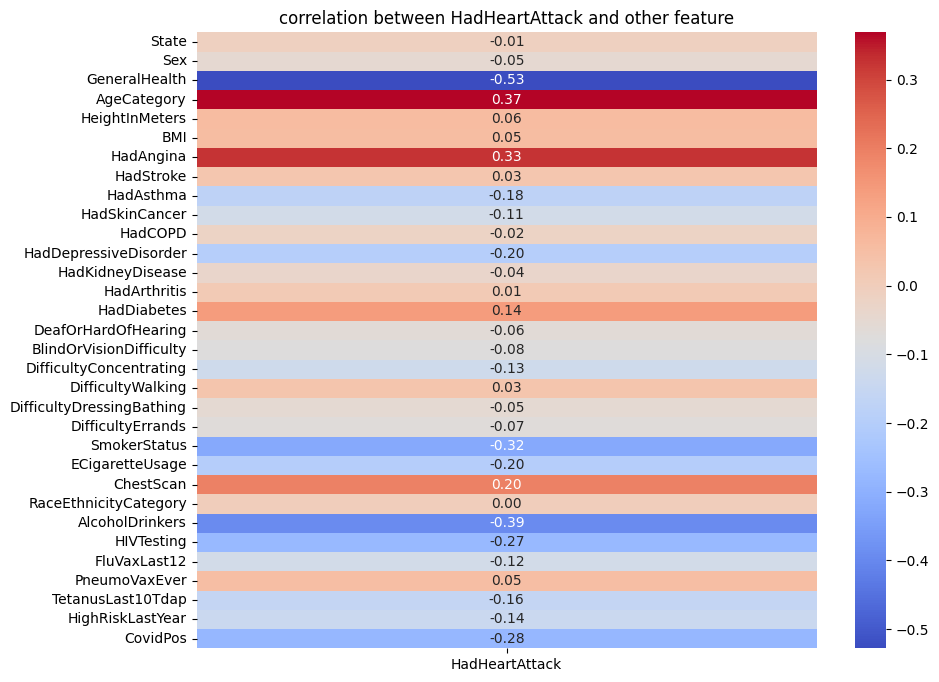

In [ ]:
plt.figure(figsize=(10,8))
heartattack_corr=df.corr()['HadHeartAttack']
heartattack_corr=heartattack_corr.drop('HadHeartAttack')

sns.heatmap(heartattack_corr.to_frame(),annot=True,fmt='0.2f',cmap='coolwarm',annot_kws={'size':10})
plt.title('correlation between HadHeartAttack and other feature')
plt.show()

In [ ]:
df.drop(['State','Sex','HeightInMeters','BMI','HadAsthma','HadSkinCancer','HadDepressiveDisorder','BlindOrVisionDifficulty',
         'DifficultyConcentrating','ECigaretteUsage','RaceEthnicityCategory','HIVTesting','FluVaxLast12','TetanusLast10Tdap',
         'HighRiskLastYear','CovidPos'],axis=1,inplace=True)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 [Text(1, 0, 'GeneralHealth'),
  Text(2, 0, 'AgeCategory'),
  Text(3, 0, 'HadAngina'),
  Text(4, 0, 'HadStroke'),
  Text(5, 0, 'HadCOPD'),
  Text(6, 0, 'HadKidneyDisease'),
  Text(7, 0, 'HadArthritis'),
  Text(8, 0, 'HadDiabetes'),
  Text(9, 0, 'DeafOrHardOfHearing'),
  Text(10, 0, 'DifficultyWalking'),
  Text(11, 0, 'DifficultyDressingBathing'),
  Text(12, 0, 'DifficultyErrands'),
  Text(13, 0, 'SmokerStatus'),
  Text(14, 0, 'ChestScan'),
  Text(15, 0, 'AlcoholDrinkers'),
  Text(16, 0, 'PneumoVaxEver'),
  Text(17, 0, 'HadHeartAttack')])

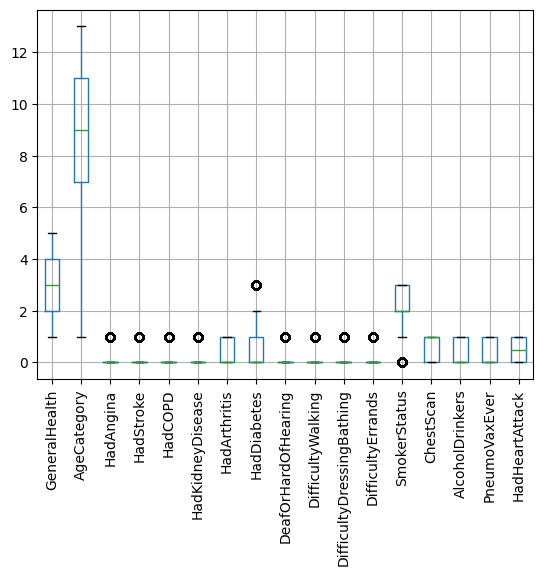

In [ ]:
df.boxplot()
plt.xticks(rotation=90)


In [ ]:
df

,GeneralHealth,AgeCategory,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ChestScan,AlcoholDrinkers,PneumoVaxEver,HadHeartAttack
1,4,10,0,0,0,0,1,0,0,0,0,0,2,0,0,1,0
2,5,9,0,0,0,0,0,0,0,0,0,0,3,0,1,0,0
4,3,7,0,0,0,0,0,0,0,0,0,0,3,1,0,0,0
6,3,11,0,0,0,0,1,0,0,0,0,0,3,1,1,0,0
9,3,13,0,0,0,0,1,0,0,0,0,0,3,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448849,3,8,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1
448850,2,10,0,0,0,0,1,0,0,0,0,0,2,1,0,0,1
448851,2,8,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1
448853,2,9,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

features=['GeneralHealth','AgeCategory','HadAngina','HadStroke','HadCOPD','HadKidneyDisease','HadArthritis','HadDiabetes','DeafOrHardOfHearing',
          'DifficultyWalking','DifficultyDressingBathing','DifficultyErrands','SmokerStatus','ChestScan','AlcoholDrinkers','PneumoVaxEver']

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x=scaled_df
y=df['HadHeartAttack']

kf=KFold(n_splits=6,shuffle=True,random_state=42)
model=LogisticRegression()

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(x_train,y_train)

  y_pred=model.predict(x_test)
  acc=accuracy_score(y_pred,y_test)
  print(f'accuracy:{acc}')

  if acc>best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_x_train=x_train
    best_x_test=x_test
    best_y_train=y_train
    best_y_test=y_test
    best_y_pred=y_pred

print(f'\n best fold:{best_fold} with accuracy:{best_accuracy}')


accuracy:0.8656690345871666
accuracy:0.869366484220333
accuracy:0.8688424362408291
accuracy:0.8669791545359264
accuracy:0.869337370443694
accuracy:0.869628508210085

 best fold:6 with accuracy:0.869628508210085


In [ ]:
model=LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.869628508210085

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8761208804006055

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(max_iter=5000))
])

model.fit(best_x_train, best_y_train)
model.score(best_x_test, best_y_test)


0.8698323046465588

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8760626528473273

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



model=Sequential()

model.add(Dense(576,activation='relu',input_shape=(16,)))
model.add(Dense(288,activation='relu'))
model.add(Dense(144,activation='relu'))
model.add(Dense(72,activation='relu'))
model.add(Dense(36,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_x_train,best_y_train,epochs=41,batch_size=32)

Epoch 1/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.8778 - loss: 0.2902
Epoch 2/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.8768 - loss: 0.2889
Epoch 3/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.8773 - loss: 0.2894
Epoch 4/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.8772 - loss: 0.2899
Epoch 5/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.8773 - loss: 0.2887
Epoch 6/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.8779 - loss: 0.2880
Epoch 7/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.8765 - loss: 0.2892
Epoch 8/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.8785 - loss: 0.2852
Epoch 9/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.8775 - loss: 0.2868
Epoch 10/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.8770 - loss: 0.2903
Epoch 11/41
5367/5367 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.8765 - loss: 0.2886
Epoch 12/41
5367/53

In [ ]:
y_pred=model.predict(best_x_test)
print(y_pred)

loss,accuracy=model.evaluate(best_x_test,best_y_test)
print(f'Accuracy:{accuracy}')

1074/1074 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
[[0.11114689]
 [0.00549102]
 [0.07836976]
 ...
 [0.658413  ]
 [0.87526125]
 [0.84529644]]
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8966 - loss: 0.2539
Accuracy:0.8769651651382446


In [ ]:
import pickle
with open('Heart DL Model.pkl',"wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/Heart DL Model.pkl",'rb')as file:
  load_model=pickle.load(file)

In [ ]:
best_x_test

,GeneralHealth,AgeCategory,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ChestScan,AlcoholDrinkers,PneumoVaxEver
5,0.50,0.583333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
15,0.75,0.250000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
16,0.50,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
18,1.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
26,0.75,0.250000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206062,0.50,0.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,0.0,1.0
206066,0.50,0.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,1.0,0.0
206074,0.50,0.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
206078,0.25,0.916667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
a=load_model.predict(np.array([[0.50,	0.833333,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.5,	1.0,	0.0,	1.0]]))
print(np.round(a))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[1.]]


In [ ]:
b=load_model.predict(np.array([[0.25,	0.916667,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	0.0,	1.0,	0.0,	0.0,	1.0]]))
print(np.round(b))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[1.]]


# Conclusion

In this heart attack prediction project, both Machine Learning (ML) and Deep Learning (DL) techniques were applied and evaluated. The ML models, including Decision Tree, Random Forest, and Support Vector Machine (SVM), were assessed using K-Fold cross-validation to ensure robust and reliable performance. While these ML models demonstrated satisfactory accuracy, the Deep Learning model achieved superior performance, making it the most effective approach for this project. The finalized model was saved and uploaded in pickle format to support future deployment and reuse.